# ISLR Python — Chapter 12, Applied Question 9

This notebook completes Applied Question 9 on the `USArrests` data. The task is to perform hierarchical clustering on the 50 U.S. states using complete linkage and Euclidean distance, cut the dendrogram to obtain three clusters, repeat the clustering after scaling the variables to standard deviation one, and compare the impact of scaling.

The data contain four variables: `Murder`, `Assault`, `UrbanPop`, and `Rape`. Because these variables are on different scales, the comparison between unscaled and scaled clustering is important.


In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from io import StringIO
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_colwidth", 120)


In [2]:
# Load USArrests data.
# The data are included directly so the notebook runs without internet access.
data_csv = """State,Murder,Assault,UrbanPop,Rape
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6
Colorado,7.9,204,78,38.7
Connecticut,3.3,110,77,11.1
Delaware,5.9,238,72,15.8
Florida,15.4,335,80,31.9
Georgia,17.4,211,60,25.8
Hawaii,5.3,46,83,20.2
Idaho,2.6,120,54,14.2
Illinois,10.4,249,83,24.0
Indiana,7.2,113,65,21.0
Iowa,2.2,56,57,11.3
Kansas,6.0,115,66,18.0
Kentucky,9.7,109,52,16.3
Louisiana,15.4,249,66,22.2
Maine,2.1,83,51,7.8
Maryland,11.3,300,67,27.8
Massachusetts,4.4,149,85,16.3
Michigan,12.1,255,74,35.1
Minnesota,2.7,72,66,14.9
Mississippi,16.1,259,44,17.1
Missouri,9.0,178,70,28.2
Montana,6.0,109,53,16.4
Nebraska,4.3,102,62,16.5
Nevada,12.2,252,81,46.0
New Hampshire,2.1,57,56,9.5
New Jersey,7.4,159,89,18.8
New Mexico,11.4,285,70,32.1
New York,11.1,254,86,26.1
North Carolina,13.0,337,45,16.1
North Dakota,0.8,45,44,7.3
Ohio,7.3,120,75,21.4
Oklahoma,6.6,151,68,20.0
Oregon,4.9,159,67,29.3
Pennsylvania,6.3,106,72,14.9
Rhode Island,3.4,174,87,8.3
South Carolina,14.4,279,48,22.5
South Dakota,3.8,86,45,12.8
Tennessee,13.2,188,59,26.9
Texas,12.7,201,80,25.5
Utah,3.2,120,80,22.9
Vermont,2.2,48,32,11.2
Virginia,8.5,156,63,20.7
Washington,4.0,145,73,26.2
West Virginia,5.7,81,39,9.3
Wisconsin,2.6,53,66,10.8
Wyoming,6.8,161,60,15.6
"""

USArrests = pd.read_csv(StringIO(data_csv)).set_index("State")
USArrests.head()


,Murder,Assault,UrbanPop,Rape
State,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


In [3]:
# Quick check of variable scales
summary = pd.DataFrame({
    "Mean": USArrests.mean(),
    "Std. Dev.": USArrests.std(),
    "Variance": USArrests.var()
}).round(2)

summary


,Mean,Std. Dev.,Variance
Murder,7.79,4.36,18.97
Assault,170.76,83.34,6945.17
UrbanPop,65.54,14.47,209.52
Rape,21.23,9.37,87.73


## (a) Complete-linkage hierarchical clustering with Euclidean distance

The first dendrogram uses the original, unscaled variables. Since `Assault` has much larger variance than the other variables, it strongly influences the Euclidean distances.


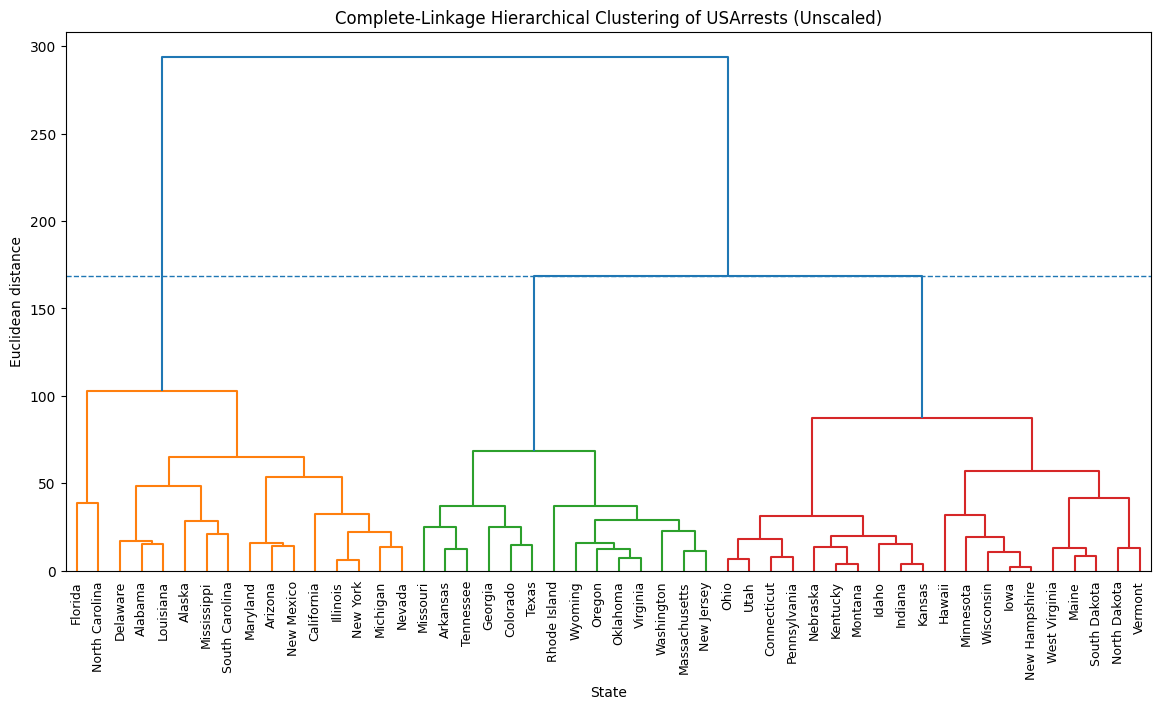

0     64.994
1     68.762
2     87.326
3    102.862
4    168.611
5    293.623
Name: Last merge heights, dtype: float64

In [4]:
# Hierarchical clustering on unscaled data
Z_unscaled = linkage(USArrests, method="complete", metric="euclidean")

plt.figure(figsize=(14, 7))
dendrogram(
    Z_unscaled,
    labels=USArrests.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=168.61
)
plt.title("Complete-Linkage Hierarchical Clustering of USArrests (Unscaled)")
plt.xlabel("State")
plt.ylabel("Euclidean distance")
plt.axhline(y=168.61, linestyle="--", linewidth=1)
plt.show()

# Show the largest merge heights to identify a cut that gives three clusters
pd.Series(Z_unscaled[-6:, 2], name="Last merge heights").round(3)


## (b) Cut the dendrogram to obtain three clusters

Cutting the unscaled dendrogram between about 102.86 and 168.61 produces three clusters. The code below uses the equivalent `maxclust=3` setting and reports the state membership.


In [5]:
# Cut unscaled dendrogram into 3 clusters
clusters_unscaled = fcluster(Z_unscaled, t=3, criterion="maxclust")

unscaled_result = (
    pd.DataFrame({"State": USArrests.index, "Cluster_Unscaled": clusters_unscaled})
    .sort_values(["Cluster_Unscaled", "State"])
)

unscaled_membership = (
    unscaled_result
    .groupby("Cluster_Unscaled")["State"]
    .apply(lambda x: ", ".join(x))
    .reset_index()
)

unscaled_membership


,Cluster_Unscaled,State
0,1,"Alabama, Alaska, Arizona, California, Delaware, Florida, Illinois, Louisiana, Maryland, Michigan, Mississippi, Nevad..."
1,2,"Arkansas, Colorado, Georgia, Massachusetts, Missouri, New Jersey, Oklahoma, Oregon, Rhode Island, Tennessee, Texas, ..."
2,3,"Connecticut, Hawaii, Idaho, Indiana, Iowa, Kansas, Kentucky, Maine, Minnesota, Montana, Nebraska, New Hampshire, Nor..."


In [6]:
# Cluster profiles for unscaled clustering
unscaled_profiles = (
    USArrests.assign(Cluster_Unscaled=clusters_unscaled)
    .groupby("Cluster_Unscaled")
    .mean()
    .round(2)
)

unscaled_profiles


,Murder,Assault,UrbanPop,Rape
Cluster_Unscaled,,,,
1,11.81,272.56,68.31,28.38
2,8.21,173.29,70.64,22.84
3,4.27,87.55,59.75,14.39


## (c) Complete-linkage hierarchical clustering after scaling

The second dendrogram standardizes each variable to mean zero and standard deviation one before computing Euclidean distances. This gives each crime/population variable equal weight in the clustering.


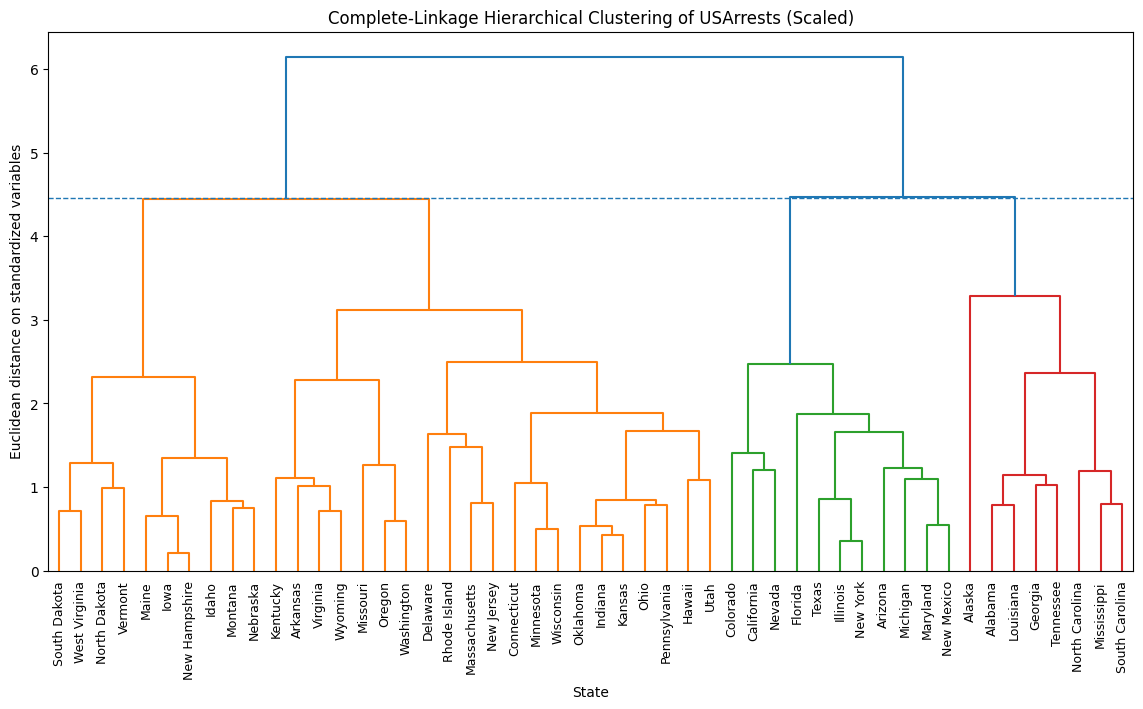

0    2.500
1    3.120
2    3.288
3    4.445
4    4.465
5    6.138
Name: Last merge heights, dtype: float64

In [7]:
# Scale the variables to mean 0 and standard deviation 1
scaler = StandardScaler()
USArrests_scaled = scaler.fit_transform(USArrests)

# Hierarchical clustering on scaled data
Z_scaled = linkage(USArrests_scaled, method="complete", metric="euclidean")

plt.figure(figsize=(14, 7))
dendrogram(
    Z_scaled,
    labels=USArrests.index.tolist(),
    leaf_rotation=90,
    leaf_font_size=9,
    color_threshold=4.46
)
plt.title("Complete-Linkage Hierarchical Clustering of USArrests (Scaled)")
plt.xlabel("State")
plt.ylabel("Euclidean distance on standardized variables")
plt.axhline(y=4.46, linestyle="--", linewidth=1)
plt.show()

pd.Series(Z_scaled[-6:, 2], name="Last merge heights").round(3)


In [8]:
# Cut scaled dendrogram into 3 clusters
clusters_scaled = fcluster(Z_scaled, t=3, criterion="maxclust")

scaled_result = (
    pd.DataFrame({"State": USArrests.index, "Cluster_Scaled": clusters_scaled})
    .sort_values(["Cluster_Scaled", "State"])
)

scaled_membership = (
    scaled_result
    .groupby("Cluster_Scaled")["State"]
    .apply(lambda x: ", ".join(x))
    .reset_index()
)

scaled_membership


,Cluster_Scaled,State
0,1,"Arkansas, Connecticut, Delaware, Hawaii, Idaho, Indiana, Iowa, Kansas, Kentucky, Maine, Massachusetts, Minnesota, Mi..."
1,2,"Arizona, California, Colorado, Florida, Illinois, Maryland, Michigan, Nevada, New Mexico, New York, Texas"
2,3,"Alabama, Alaska, Georgia, Louisiana, Mississippi, North Carolina, South Carolina, Tennessee"


In [9]:
# Cluster profiles for scaled clustering, reported on original units for interpretation
scaled_profiles = (
    USArrests.assign(Cluster_Scaled=clusters_scaled)
    .groupby("Cluster_Scaled")
    .mean()
    .round(2)
)

scaled_profiles


,Murder,Assault,UrbanPop,Rape
Cluster_Scaled,,,,
1,5.00,116.48,63.84,16.34
2,11.05,264.09,79.09,32.62
3,14.09,252.75,53.50,24.54


## (d) Effect of scaling and interpretation

Scaling changes the clustering substantially. In the unscaled analysis, the large variance of `Assault` dominates the Euclidean distance, so states are separated mainly by assault levels. After standardization, `Murder`, `Assault`, `UrbanPop`, and `Rape` contribute more equally. The scaled solution is more interpretable because the variables are measured on different scales: crime rates and urban population percentage should not be allowed to dominate merely because of their units. Therefore, scaling is preferred for this analysis.


In [10]:
# Compare unscaled and scaled cluster assignments
comparison = pd.DataFrame({
    "Cluster_Unscaled": clusters_unscaled,
    "Cluster_Scaled": clusters_scaled
}, index=USArrests.index)

pd.crosstab(comparison["Cluster_Unscaled"], comparison["Cluster_Scaled"])


Cluster_Scaled,1,2,3
Cluster_Unscaled,,,
1,1,9,6
2,10,2,2
3,20,0,0
